In [ ]:
import pandas as pd

dF = pd.read_csv("/content/heart_disease_dataset (1).csv")

rowsToDelete = [407, 909]
need_To_Delete = [r - 2 for r in rowsToDelete]


need_To_Delete = [i for i in need_To_Delete if i in dF.index]

print("Rows to delete:")
print(dF.loc[need_To_Delete])

dF_Cleaned = dF.drop(index=need_To_Delete).reset_index(drop=True)

print("Original shape:", dF.shape)
print("After removing rows:", dF_Cleaned.shape)

dF_Cleaned.to_csv("/content/heart_disease_combined.csv", index=False)



Rows to delete:
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
405  49.0  0.0  2.0     110.0    NaN  0.0      0.0    160.0    0.0      0.0   
907  58.0  1.0  3.0     150.0  219.0  0.0      1.0    118.0    1.0      0.0   

     slope  ca  thal  target     source  
405    NaN NaN   NaN       0  hungarian  
907    NaN NaN   NaN       2         va  
Original shape: (920, 15)
After removing rows: (918, 15)


In [ ]:
import pandas as pd

dF = pd.read_csv("/content/heart_disease_dataset (1).csv")

mData = (dF["chol"]== 0) | (dF["trestbps"] == 0)

print("Rows with missing values :",mData.sum())
df_Cleaned = dF[~mData].reset_index(drop=True)

print("Original Data Representation:",dF.shape)
print("Modify the missing values:",df_Cleaned.shape)

df_Cleaned.to_csv("/content/heart_disease_dataset (1).csv",index=False)

Rows with missing values : 172
Original Data Representation: (920, 15)
Modify the missing values: (748, 15)


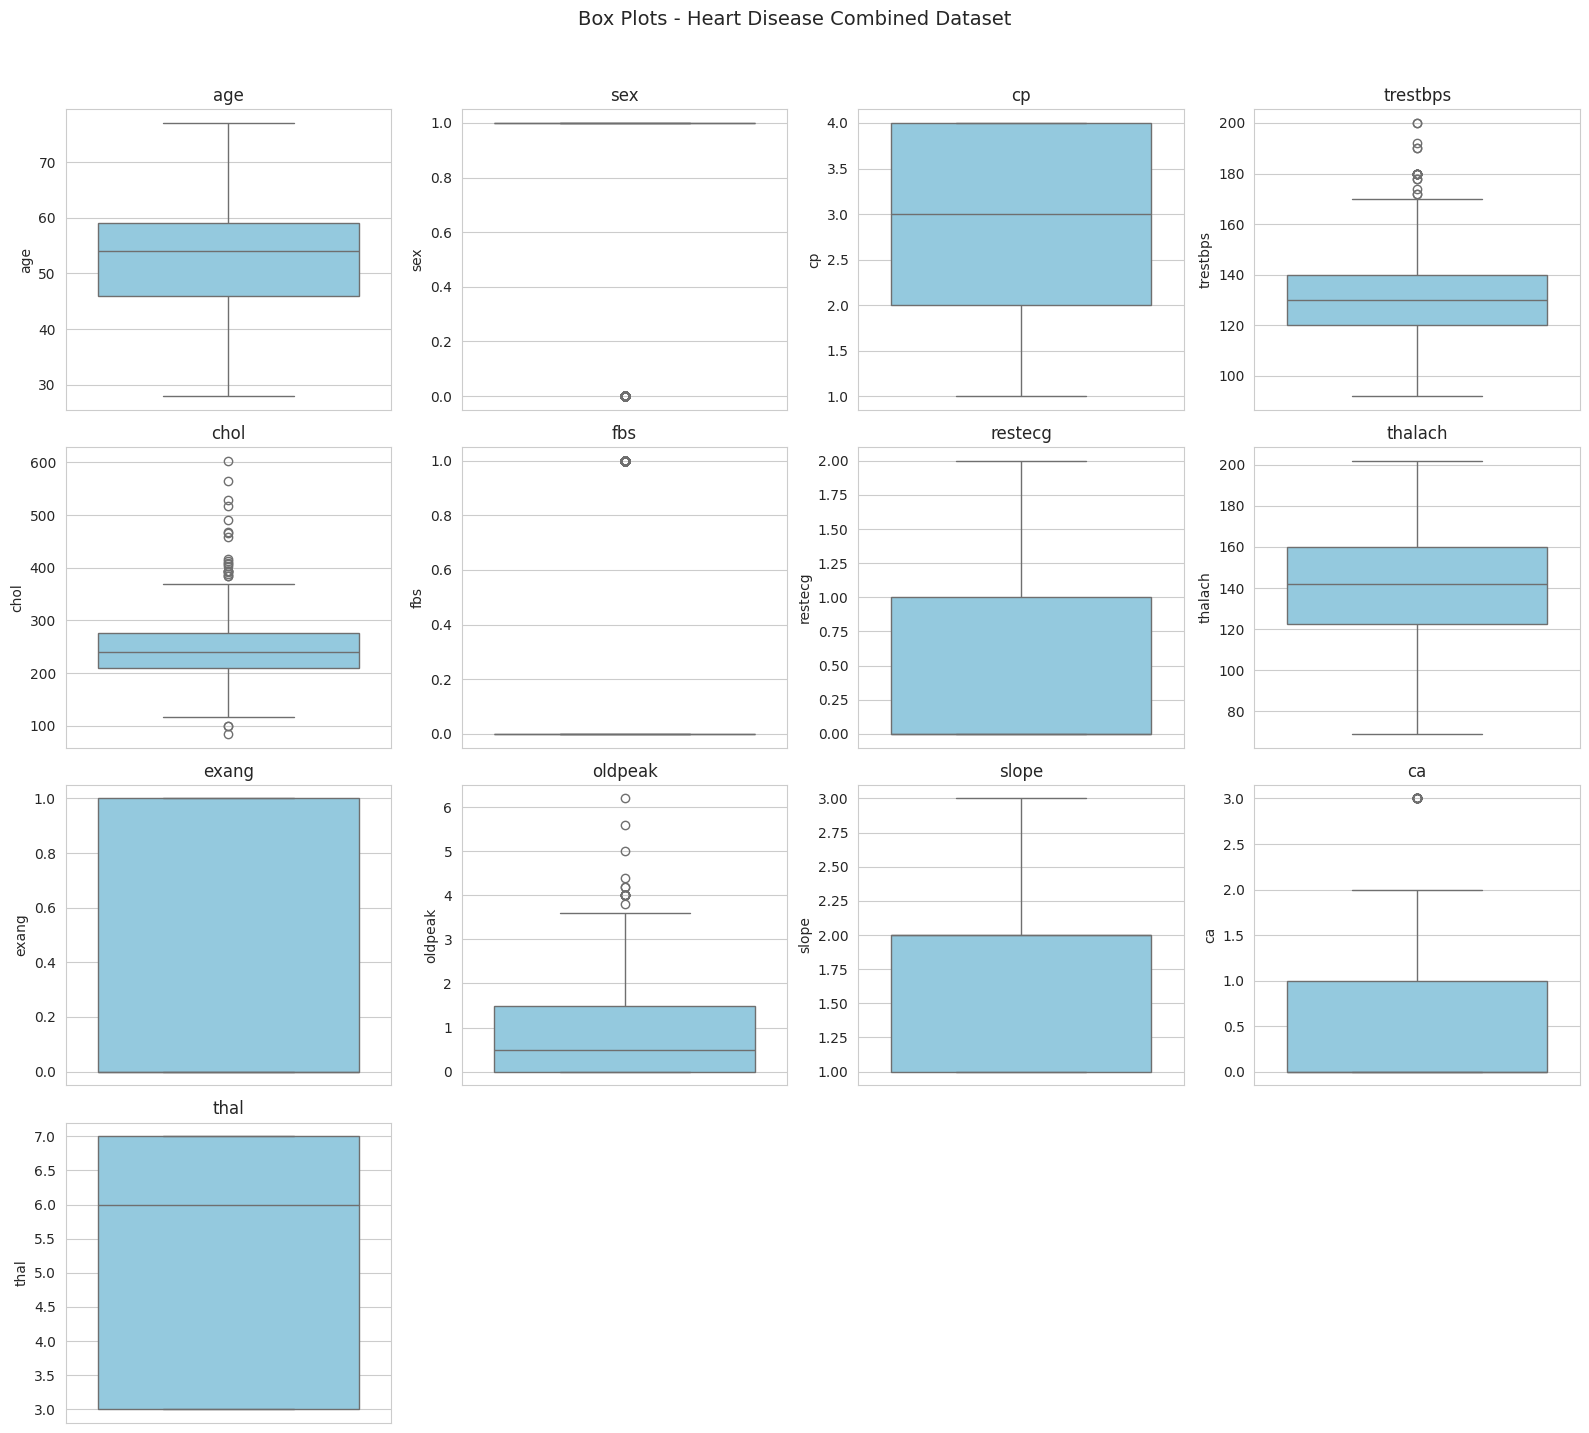

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

dF_Cleaned = pd.read_csv("/content/heart_disease_dataset (1).csv")

numeric_cols = dF_Cleaned.select_dtypes(include="number").columns.tolist()
numeric_cols.remove("target")

n_cols = 4
n_rows = -(-len(numeric_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=dF_Cleaned[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Box Plots - Heart Disease Combined Dataset", fontsize=14, y=1.02)
plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = "results/eda_visualizations"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()


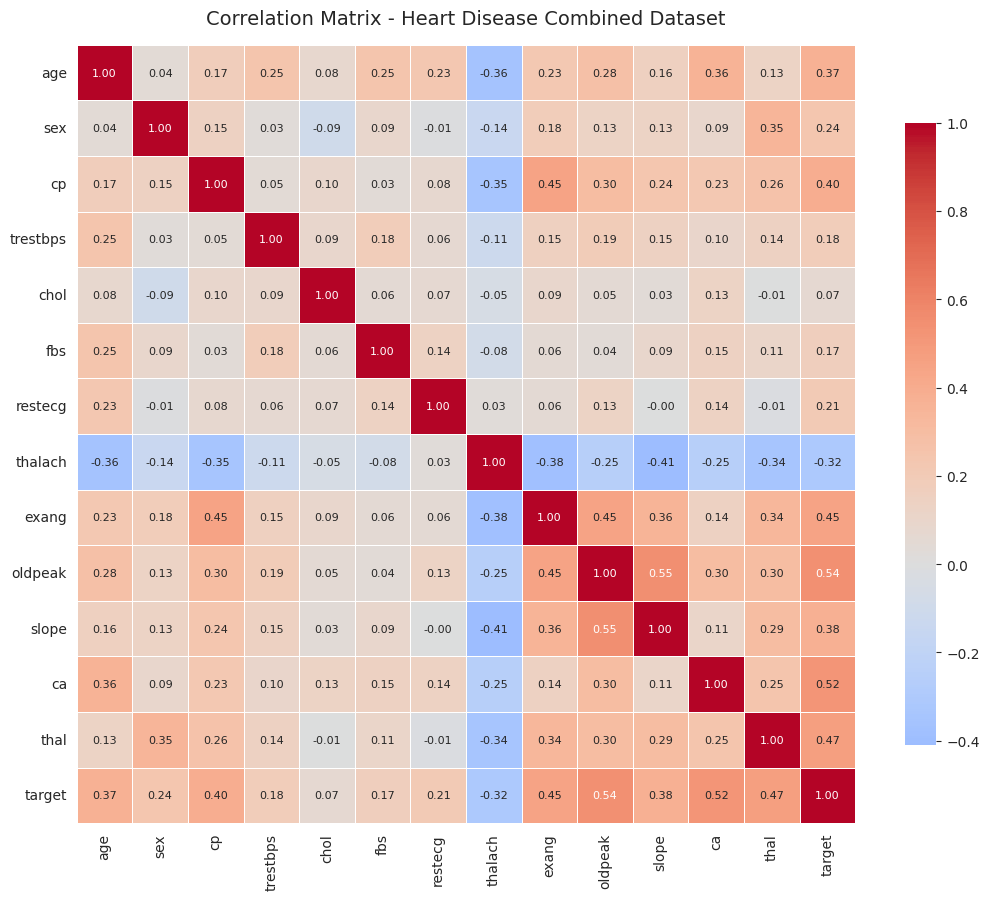

In [ ]:
numeric_df = dF_Cleaned.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
plt.title("Correlation Matrix - Heart Disease Combined Dataset", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("results/eda_visualizations/correlation_matrix.png", dpi=150)
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv("heart_disease_combined.csv")
df.head()
df.dtypes
df["source"].unique()

array(['cleveland', 'hungarian', 'va'], dtype=object)

In [ ]:
import pandas as pd
df = pd.read_csv("heart_disease_combined.csv")
df["source"].value_counts()
df_encoded = pd.get_dummies(df,columns=["source"],dtype=int)
df_encoded.head()
df_encoded[df_encoded["source_hungarian"] == 1].head()
df_encoded[df_encoded["source_va"] == 1].head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source_cleveland,source_hungarian,source_va
596,63.0,1.0,4.0,140.0,260.0,0.0,1.0,112.0,1.0,3.0,2.0,NaN,NaN,2,0,0,1
597,44.0,1.0,4.0,130.0,209.0,0.0,1.0,127.0,0.0,0.0,NaN,NaN,NaN,0,0,0,1
598,60.0,1.0,4.0,132.0,218.0,0.0,1.0,140.0,1.0,1.5,3.0,NaN,NaN,2,0,0,1
599,55.0,1.0,4.0,142.0,228.0,0.0,1.0,149.0,1.0,2.5,1.0,NaN,NaN,1,0,0,1
600,66.0,1.0,3.0,110.0,213.0,1.0,2.0,99.0,1.0,1.3,2.0,NaN,NaN,0,0,0,1


In [ ]:
print("Original Shape :", df.shape)
print("Encoded Shape  :", df_encoded.shape)

Original Shape : (747, 15)
Encoded Shape  : (747, 17)


In [ ]:
source_cols = [c for c in df_encoded.columns if c.startswith("source_")]
print("Encoded source columns:", source_cols)

comparison = pd.DataFrame({"Original Source": df["source"]})

for c in source_cols:
    comparison[c.replace("source_", "").capitalize()] = df_encoded[c]

comparison.tail(10)

Encoded source columns: ['source_cleveland', 'source_hungarian', 'source_va']


,Original Source,Cleveland,Hungarian,Va
737,va,0,0,1
738,va,0,0,1
739,va,0,0,1
740,va,0,0,1
741,va,0,0,1
742,va,0,0,1
743,va,0,0,1
744,va,0,0,1
745,va,0,0,1
746,va,0,0,1


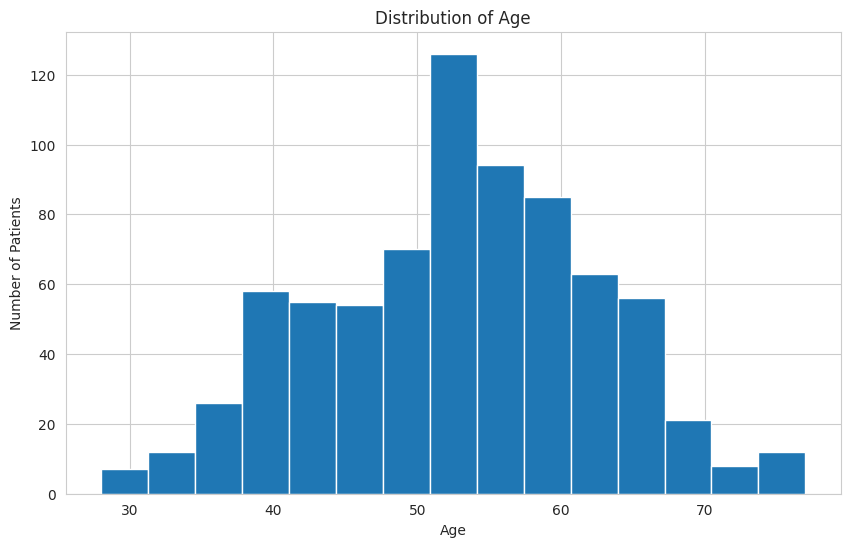

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df["age"], bins=15)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

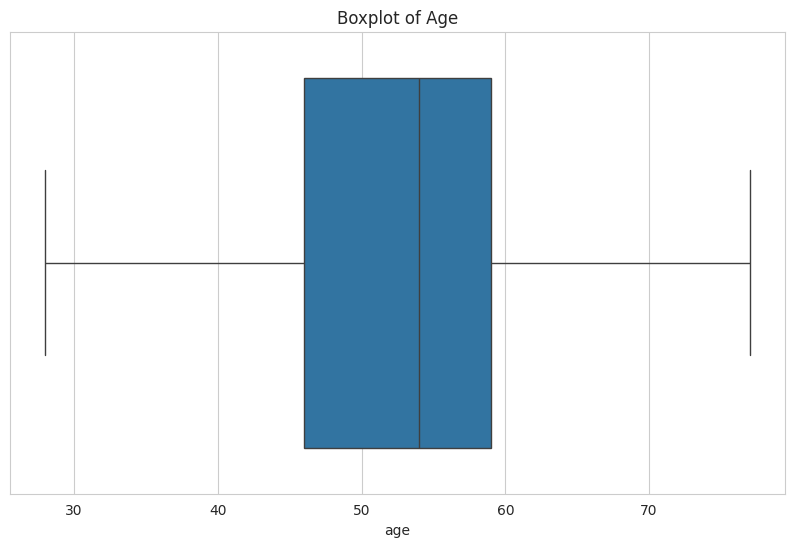

In [ ]:
import seaborn as sns
sns.boxplot(x=df["age"])
plt.title("Boxplot of Age")
plt.show()

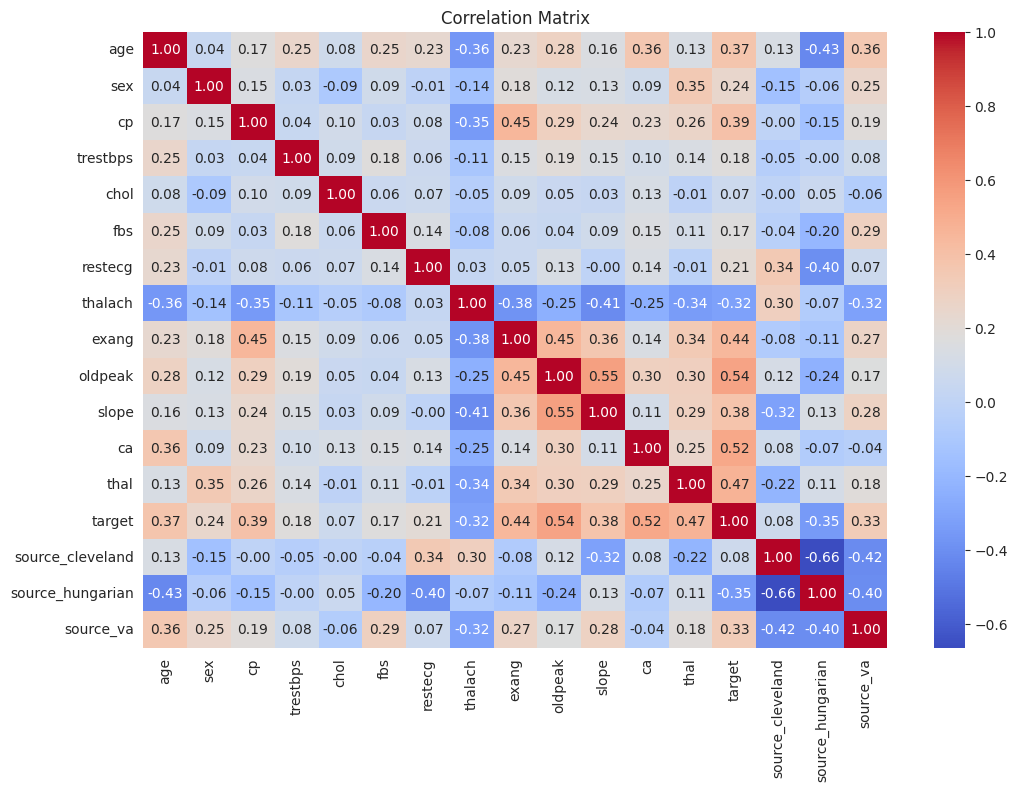

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(),cmap="coolwarm",annot=True,fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

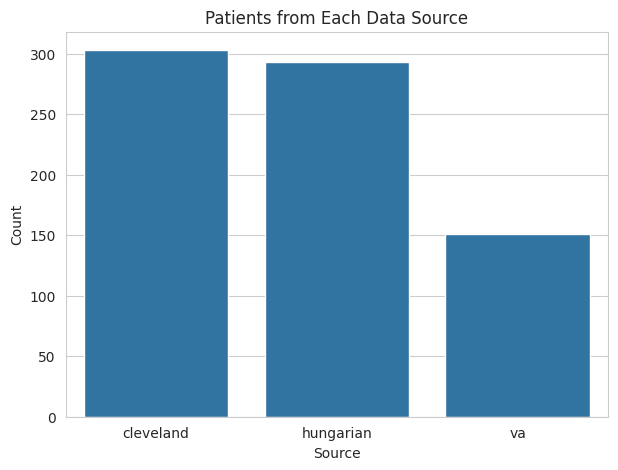

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x="source", data=df)

plt.title("Patients from Each Data Source")
plt.xlabel("Source")
plt.ylabel("Count")

plt.show()

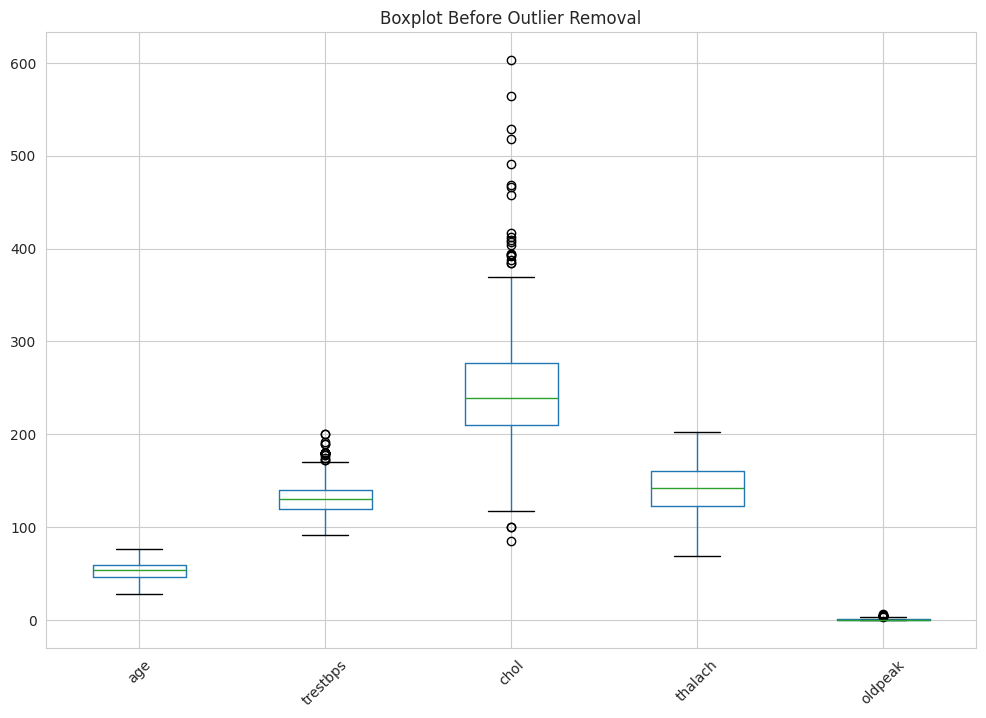

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/content/heart_disease_dataset (1).csv')
df.head()
df.shape
numerical_columns = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

plt.figure(figsize=(12, 8))

df[numerical_columns].boxplot()

plt.title('Boxplot Before Outlier Removal')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_clean = df.copy()

for col in numerical_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower_bound) &
        (df_clean[col] <= upper_bound) |
        (df_clean[col].isna())
    ]

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)

Original shape: (748, 15)
After outlier removal: (694, 15)


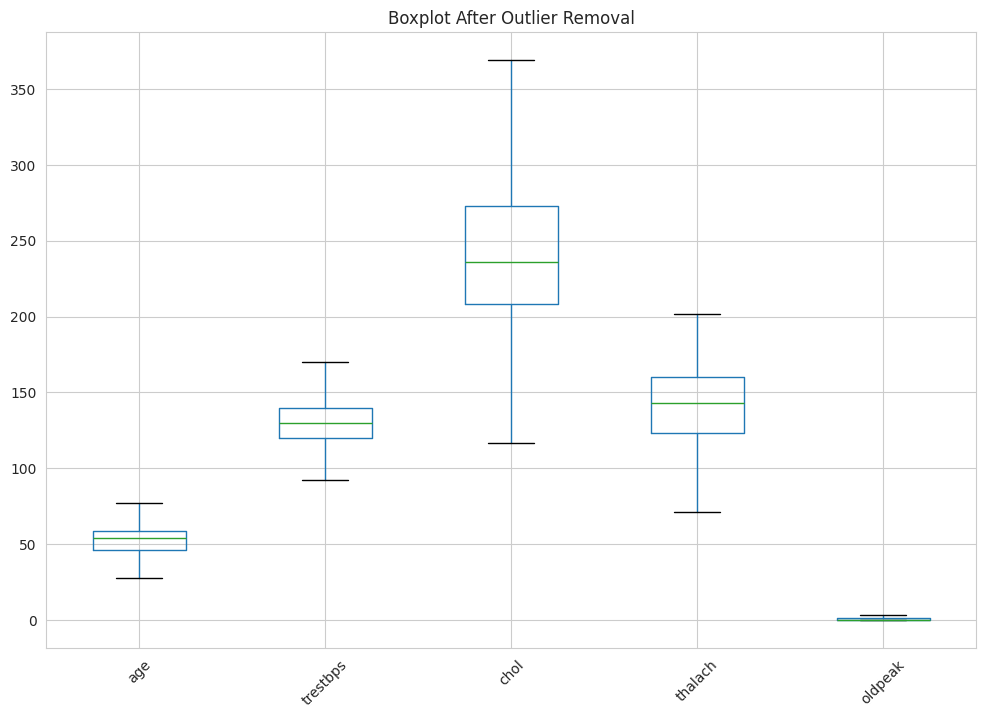

In [ ]:
plt.figure(figsize=(12, 8))

df_clean[numerical_columns].boxplot()

plt.title('Boxplot After Outlier Removal')
plt.xticks(rotation=45)
plt.show()

In [ ]:
rows_removed = len(df) - len(df_clean)

print("Rows before:", len(df))
print("Rows after:", len(df_clean))
print("Rows removed:", rows_removed)

Rows before: 748
Rows after: 694
Rows removed: 54


In [ ]:
import pandas as pd

df= pd.read_csv("/content/heart_disease_combined.csv")


df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:

print("Dataset shape:", df.shape)


print(df.dtypes)


print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (918, 15)
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
source       object
dtype: object

Missing values:
age           0
sex           0
cp            0
trestbps     59
chol         29
fbs          90
restecg       2
thalach      55
exang        55
oldpeak      62
slope       307
ca          609
thal        484
target        0
source        0
dtype: int64


In [ ]:
X = df.drop(columns=['target', 'source'])

# Target variable
y = df['target']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  
3    3.0  0.0   3.0  
4    1.0  0.0   3.0  

Target:
0    0
1    2
2    1
3    0
4    0
Name: target, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert X_scaled back to a DataFrame for easier manipulation and to retain column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Mean of scaled features:")
print(X_scaled.mean())

print("\nStandard deviation of scaled features:")
print(X_scaled.std())

Mean of scaled features:
age        -1.238419e-16
sex         0.000000e+00
cp          0.000000e+00
trestbps   -4.177230e-16
chol       -6.394085e-17
fbs        -3.432574e-17
restecg     3.102807e-17
thalach    -3.952034e-16
exang       3.293361e-17
oldpeak     1.660147e-17
slope       0.000000e+00
ca          5.748728e-17
thal       -1.309756e-16
dtype: float64

Standard deviation of scaled features:
age         1.000545
sex         1.000545
cp          1.000545
trestbps    1.000583
chol        1.000563
fbs         1.000604
restecg     1.000546
thalach     1.000580
exang       1.000580
oldpeak     1.000585
slope       1.000819
ca          1.001622
thal        1.001154
dtype: float64


In [ ]:
print("Mean of scaled features:")
print(X_scaled.mean())

print("\nStandard deviation of scaled features:")
print(X_scaled.std())

Mean of scaled features:
age        -1.238419e-16
sex         0.000000e+00
cp          0.000000e+00
trestbps   -4.177230e-16
chol       -6.394085e-17
fbs        -3.432574e-17
restecg     3.102807e-17
thalach    -3.952034e-16
exang       3.293361e-17
oldpeak     1.660147e-17
slope       0.000000e+00
ca          5.748728e-17
thal       -1.309756e-16
dtype: float64

Standard deviation of scaled features:
age         1.000545
sex         1.000545
cp          1.000545
trestbps    1.000583
chol        1.000563
fbs         1.000604
restecg     1.000546
thalach     1.000580
exang       1.000580
oldpeak     1.000585
slope       1.000819
ca          1.001622
thal        1.001154
dtype: float64


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/heart_disease_combined.csv')

# Separate features and target
X = df.drop(columns=['target', 'source'])
y = df['target']

# Create StandardScaler
scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(X)

# Convert scaled data to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display results
print("Original Data:")
print(X.head())

print("\nScaled Data:")
print(X_scaled.head())

Original Data:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  
0    3.0  0.0   6.0  
1    2.0  3.0   3.0  
2    2.0  2.0   7.0  
3    3.0  0.0   3.0  
4    1.0  0.0   3.0  

Scaled Data:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  1.006537  0.515952 -2.419749  0.675117  0.305943  2.236068  1.731199   
1  1.430829  0.515952  0.804242  1.462416  0.784374 -0.447214  1.731199   
2  1.430829  0.515952  0.804242 -0.637050  0.269835 -0.447214  1.731199   
3 -1.751359  0.515952 -0.270422 -0.112183  0.459402 -0.447214 -0.750457   
4

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate X and y
X = df.drop(columns=['target', 'source'])
y = df['target']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler on test data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (734, 13)
Testing data shape: (184, 13)


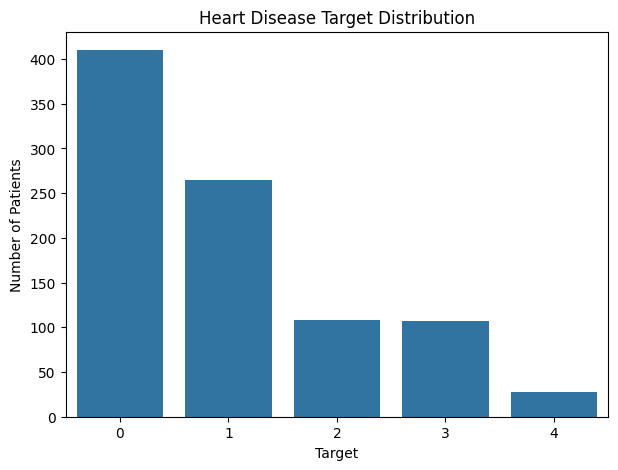

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(data=df, x='target')

plt.title('Heart Disease Target Distribution')
plt.xlabel('Target')
plt.ylabel('Number of Patients')

plt.show()

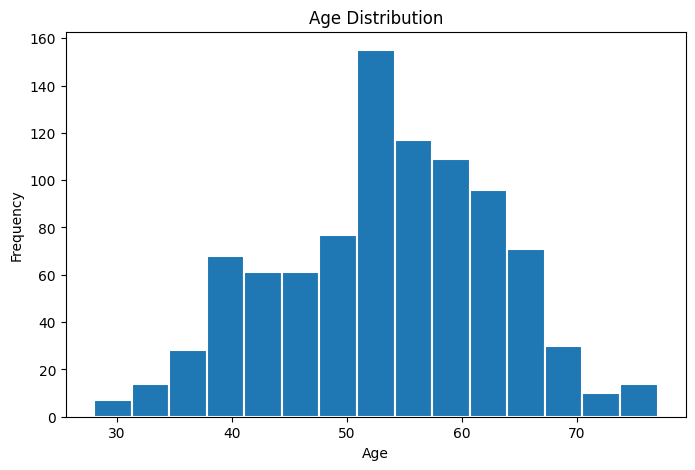

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=15,edgecolor='white',linewidth=1.5)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

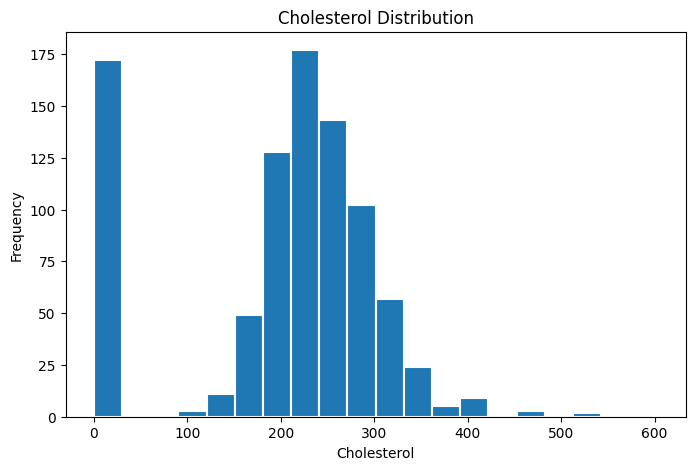

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['chol'], bins=20,edgecolor='white',linewidth=1.5)

plt.title('Cholesterol Distribution')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')

plt.show()

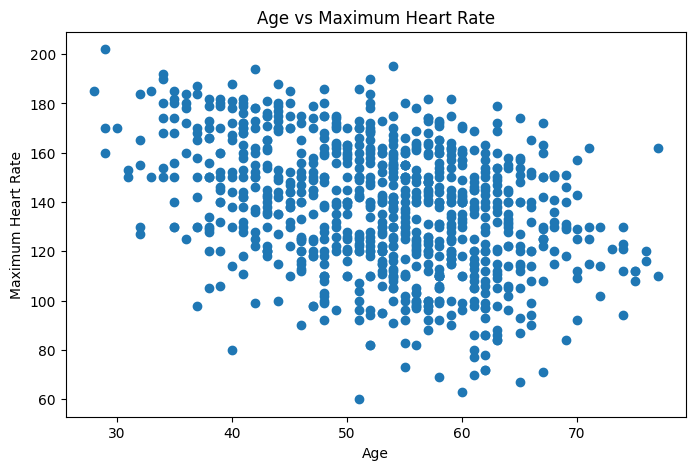

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['thalach'])

plt.title('Age vs Maximum Heart Rate')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')

plt.show()

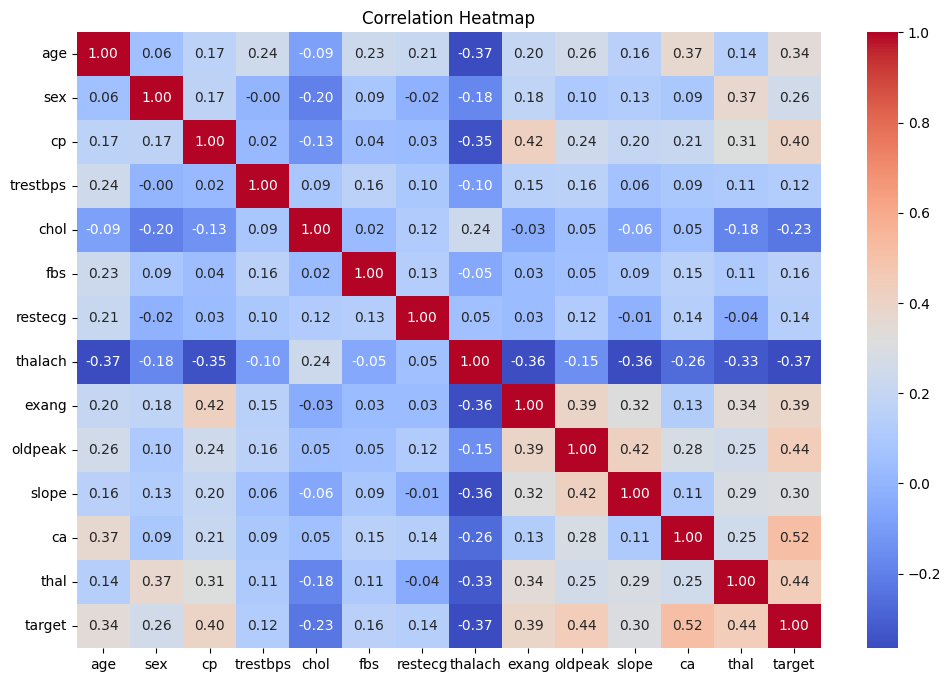

In [ ]:
plt.figure(figsize=(12,8))

correlation = df.select_dtypes(include='number').corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

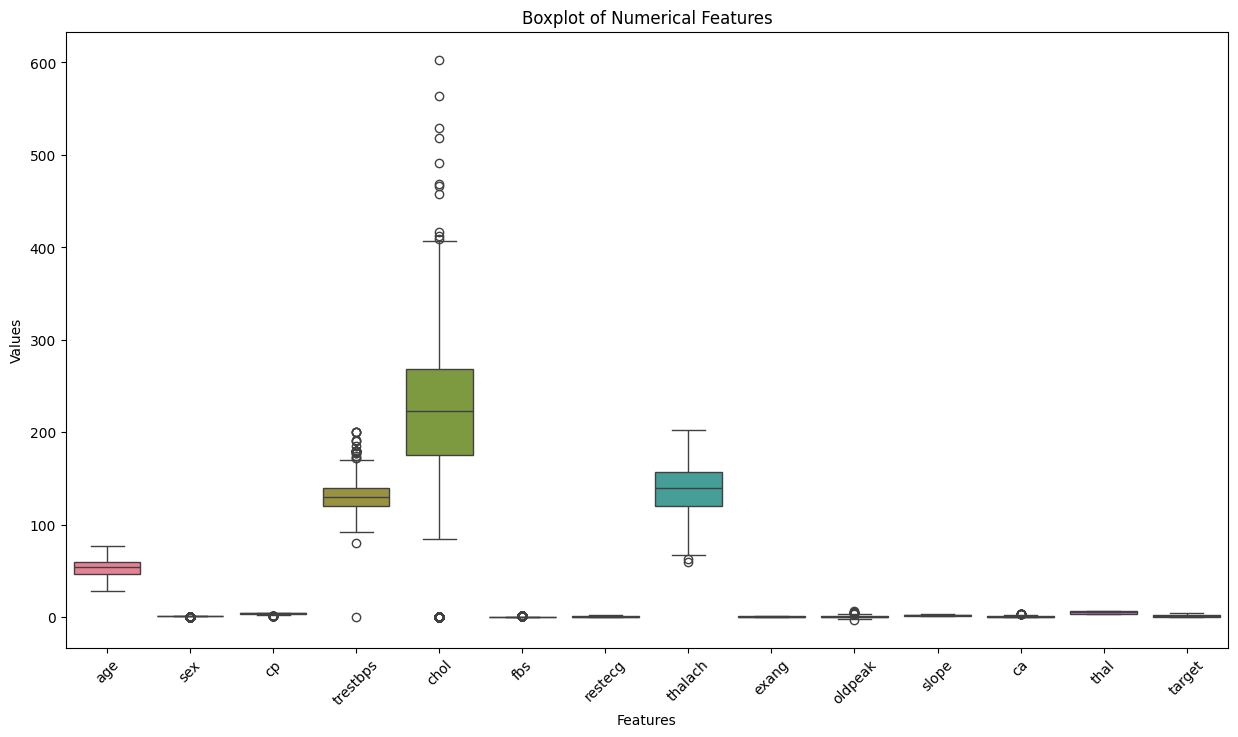

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numeric_columns = df.select_dtypes(include='number').columns

# Create boxplot
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_columns])

plt.title('Boxplot of Numerical Features')
plt.xlabel('Features')
plt.ylabel('Values')

plt.xticks(rotation=45)
plt.show()

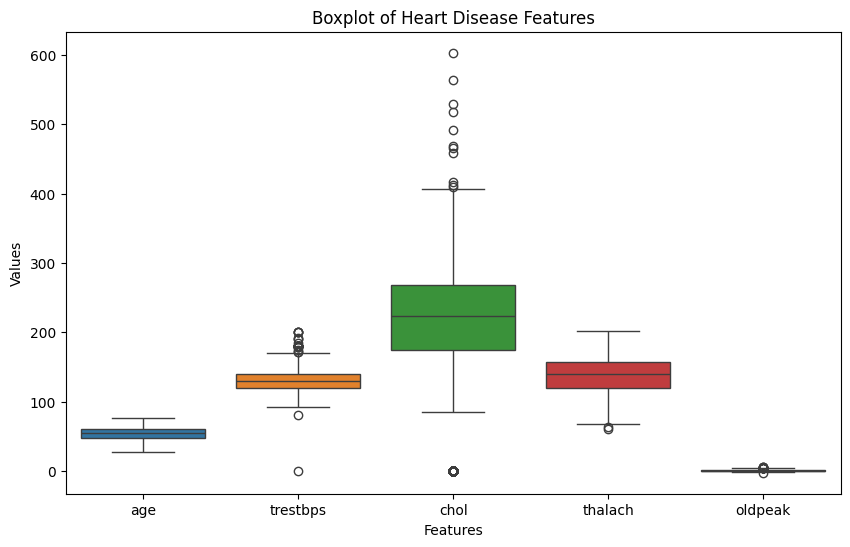

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']])

plt.title('Boxplot of Heart Disease Features')
plt.xlabel('Features')
plt.ylabel('Values')

plt.show()

In [ ]:
# Create correlation matrix
correlation_matrix = df.select_dtypes(include='number').corr()

# Display correlation matrix
print(correlation_matrix)

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000  0.055750  0.165896  0.243474 -0.086342  0.233846   
sex       0.055750  1.000000  0.168254 -0.002022 -0.197418  0.088689   
cp        0.165896  0.168254  1.000000  0.023614 -0.132529  0.039069   
trestbps  0.243474 -0.002022  0.023614  1.000000  0.092710  0.160353   
chol     -0.086342 -0.197418 -0.132529  0.092710  1.000000  0.024857   
fbs       0.233846  0.088689  0.039069  0.160353  0.024857  1.000000   
restecg   0.212217 -0.017515  0.030187  0.097498  0.116415  0.132267   
thalach  -0.365261 -0.177504 -0.348725 -0.103121  0.236365 -0.053430   
exang     0.200778  0.179541  0.419528  0.150274 -0.034853  0.029462   
oldpeak   0.258584  0.102992  0.243175  0.162032  0.047918  0.054451   
slope     0.155032  0.125154  0.202989  0.063387 -0.059276  0.092142   
ca        0.370416  0.094123  0.214975  0.093705  0.051606  0.149539   
thal      0.137298  0.373927  0.313150  0.107555 -0.179903  0.10

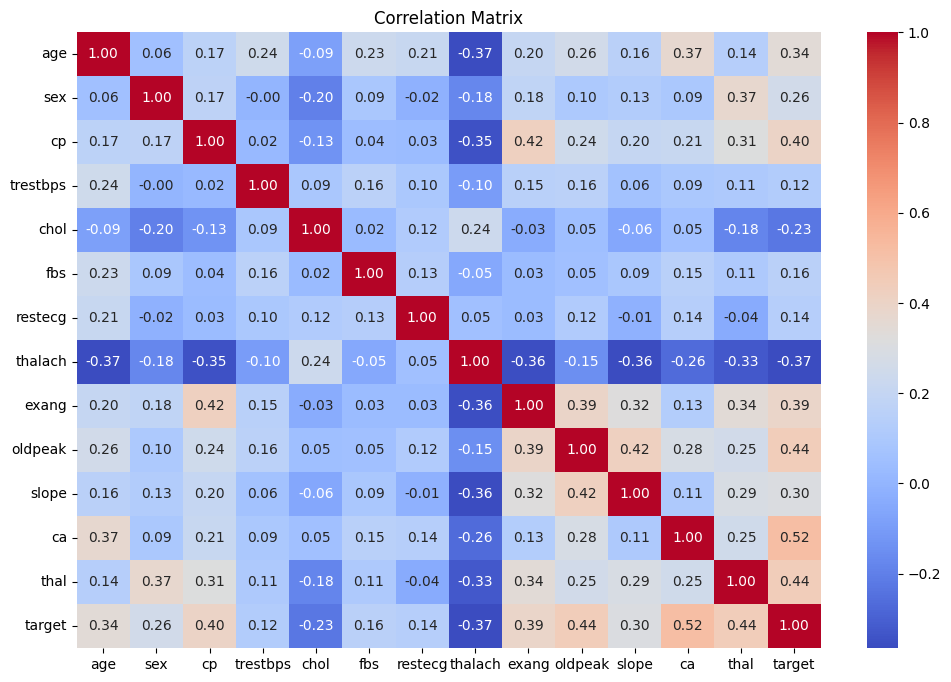

In [ ]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [ ]:
# Select numerical features
X = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']]

# Convert to matrix
matrix = X.values

print(matrix)

[[ 63.  145.  233.  150.    2.3]
 [ 67.  160.  286.  108.    1.5]
 [ 67.  120.  229.  129.    2.6]
 ...
 [ 55.  122.  223.  100.    0. ]
 [ 58.    nan 385.    nan   nan]
 [ 62.  120.  254.   93.    0. ]]


In [ ]:
print("Matrix shape:", matrix.shape)

Matrix shape: (918, 5)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('heart_disease_combined.csv')
print('Shape:', df.shape)
df.head()

Shape: (918, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum().sort_values(ascending=False))
print('\nTarget distribution:')
print(df['target'].value_counts().sort_index())
print('\nSource distribution:')
print(df['source'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    float64
 1   sex       918 non-null    float64
 2   cp        918 non-null    float64
 3   trestbps  859 non-null    float64
 4   chol      889 non-null    float64
 5   fbs       828 non-null    float64
 6   restecg   916 non-null    float64
 7   thalach   863 non-null    float64
 8   exang     863 non-null    float64
 9   oldpeak   856 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  target    918 non-null    int64  
 14  source    918 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.7+ KB

Missing values per column:
ca          609
thal        484
slope       307
fbs          90
oldpeak      62
trestbps     59
thalach      55
exang        55
chol       

In [ ]:
df['target_binary'] = (df['target'] > 0).astype(int)
df[['target', 'target_binary']].value_counts().sort_index()

,,count
target,target_binary,
0,0,410
1,1,265
2,1,108
3,1,107
4,1,28


In [ ]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_num_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

df_clean = df.copy()

num_imputer = SimpleImputer(strategy='median')
df_clean[numeric_cols] = num_imputer.fit_transform(df_clean[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df_clean[categorical_num_cols] = cat_imputer.fit_transform(df_clean[categorical_num_cols])

print('Remaining missing values:')
print(df_clean.isnull().sum().sum())

Remaining missing values:
0


In [ ]:
# Age groups
df_clean['age_group'] = pd.cut(
    df_clean['age'], bins=[0, 40, 50, 60, 70, 100],
    labels=['<40', '40-50', '50-60', '60-70', '70+']
)

# Cholesterol risk category (standard clinical thresholds)
df_clean['chol_category'] = pd.cut(
    df_clean['chol'], bins=[-1, 200, 240, 1000],
    labels=['normal', 'borderline_high', 'high']
)

# Resting blood pressure category
df_clean['bp_category'] = pd.cut(
    df_clean['trestbps'], bins=[-1, 120, 140, 1000],
    labels=['normal', 'elevated', 'high']
)

# Max heart rate reserve proxy: how close thalach is to the age-predicted max (220 - age)
df_clean['hr_reserve_pct'] = df_clean['thalach'] / (220 - df_clean['age'])

# Combined risk flag: exercise-induced angina AND ST depression present
df_clean['exercise_stress_flag'] = ((df_clean['exang'] == 1) & (df_clean['oldpeak'] > 1)).astype(int)

df_clean[['age', 'age_group', 'chol', 'chol_category', 'trestbps', 'bp_category',
          'hr_reserve_pct', 'exercise_stress_flag']].head()

,age,age_group,chol,chol_category,trestbps,bp_category,hr_reserve_pct,exercise_stress_flag
0,63.0,60-70,233.0,borderline_high,145.0,high,0.955414,0
1,67.0,60-70,286.0,high,160.0,high,0.705882,1
2,67.0,60-70,229.0,borderline_high,120.0,normal,0.843137,1
3,37.0,<40,250.0,high,130.0,elevated,1.021858,0
4,41.0,40-50,204.0,borderline_high,130.0,elevated,0.960894,0


In [ ]:
nominal_cols = ['cp', 'restecg', 'slope', 'thal', 'age_group', 'chol_category', 'bp_category']

df_encoded = pd.get_dummies(df_clean, columns=nominal_cols, prefix=nominal_cols)

# One-hot encode source too (which study the record came from)
df_encoded = pd.get_dummies(df_encoded, columns=['source'], prefix='source')

print('Shape after encoding:', df_encoded.shape)
df_encoded.head()

Shape after encoding: (918, 41)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,chol_category_normal,chol_category_borderline_high,chol_category_high,bp_category_normal,bp_category_elevated,bp_category_high,source_cleveland,source_hungarian,source_switzerland,source_va
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,...,False,True,False,False,False,True,True,False,False,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,2,...,False,False,True,False,False,True,True,False,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,...,False,True,False,True,False,False,True,False,False,False
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,...,False,False,True,False,True,False,True,False,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,...,False,True,False,False,True,False,True,False,False,False


In [ ]:
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'hr_reserve_pct']

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

df_encoded[scale_cols].describe()

,age,trestbps,chol,thalach,oldpeak,hr_reserve_pct
count,9.180000e+02,9.180000e+02,9.180000e+02,9.180000e+02,918.000000,9.180000e+02
mean,-1.238419e-16,-3.870058e-18,-1.857628e-16,4.334465e-16,0.000000,-5.263280e-16
std,1.000545e+00,1.000545e+00,1.000545e+00,1.000545e+00,1.000545,1.000545e+00
min,-2.706015e+00,-7.159324e+00,-1.832006e+00,-3.090307e+00,-3.266098,-3.318427e+00
25%,-6.906294e-01,-6.508477e-01,-2.072756e-01,-7.036483e-01,-0.808338,-7.039524e-01
50%,5.188098e-02,-1.084746e-01,2.120834e-01,9.190455e-02,-0.335692,1.122253e-01
75%,6.883185e-01,4.338985e-01,6.154015e-01,7.184024e-01,0.609600,7.512427e-01
max,2.491558e+00,3.688137e+00,3.695284e+00,2.558118e+00,5.052475,2.447802e+00


In [ ]:
print('Final columns:', list(df_encoded.columns))
print('\nFinal shape:', df_encoded.shape)

# Optional: save engineered dataset
df_encoded.to_csv('heart_disease_engineered.csv', index=False)
print('\nSaved to heart_disease_engineered.csv')

Final columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'target_binary', 'hr_reserve_pct', 'exercise_stress_flag', 'cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0', 'age_group_<40', 'age_group_40-50', 'age_group_50-60', 'age_group_60-70', 'age_group_70+', 'chol_category_normal', 'chol_category_borderline_high', 'chol_category_high', 'bp_category_normal', 'bp_category_elevated', 'bp_category_high', 'source_cleveland', 'source_hungarian', 'source_switzerland', 'source_va']

Final shape: (918, 41)

Saved to heart_disease_engineered.csv


/tmp/ipykernel_2381/3555097129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis', ax=axes[0])
/tmp/ipykernel_2381/3555097129.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target_binary', data=df_clean, palette='Set2', ax=axes[1])
/tmp/ipykernel_2381/3555097129.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Disease', 'Disease'])


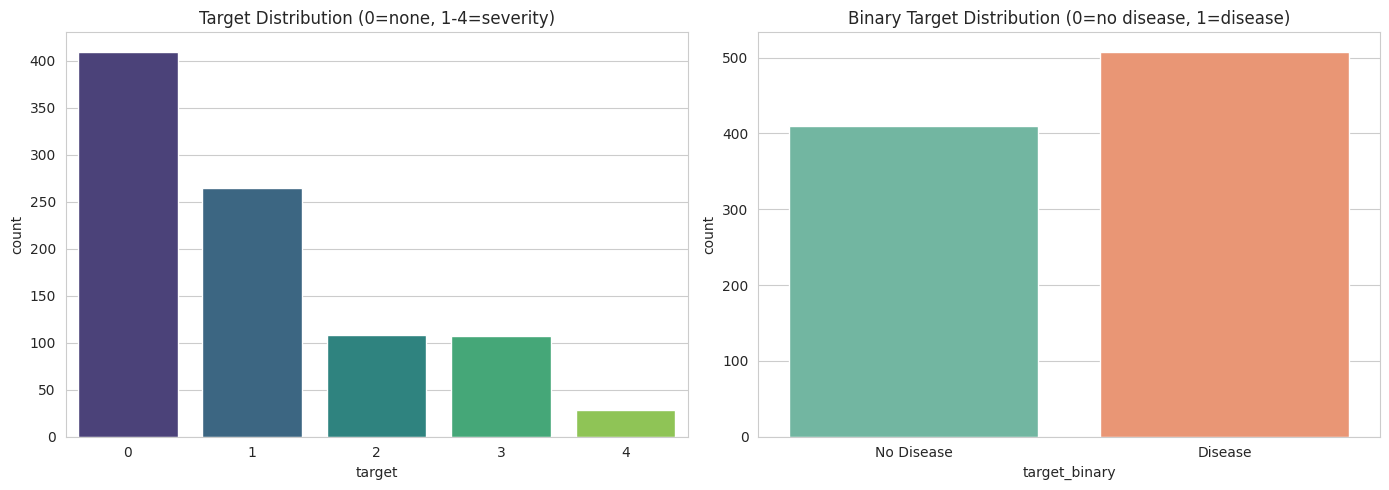

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='target', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Target Distribution (0=none, 1-4=severity)')

sns.countplot(x='target_binary', data=df_clean, palette='Set2', ax=axes[1])
axes[1].set_title('Binary Target Distribution (0=no disease, 1=disease)')
axes[1].set_xticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.show()

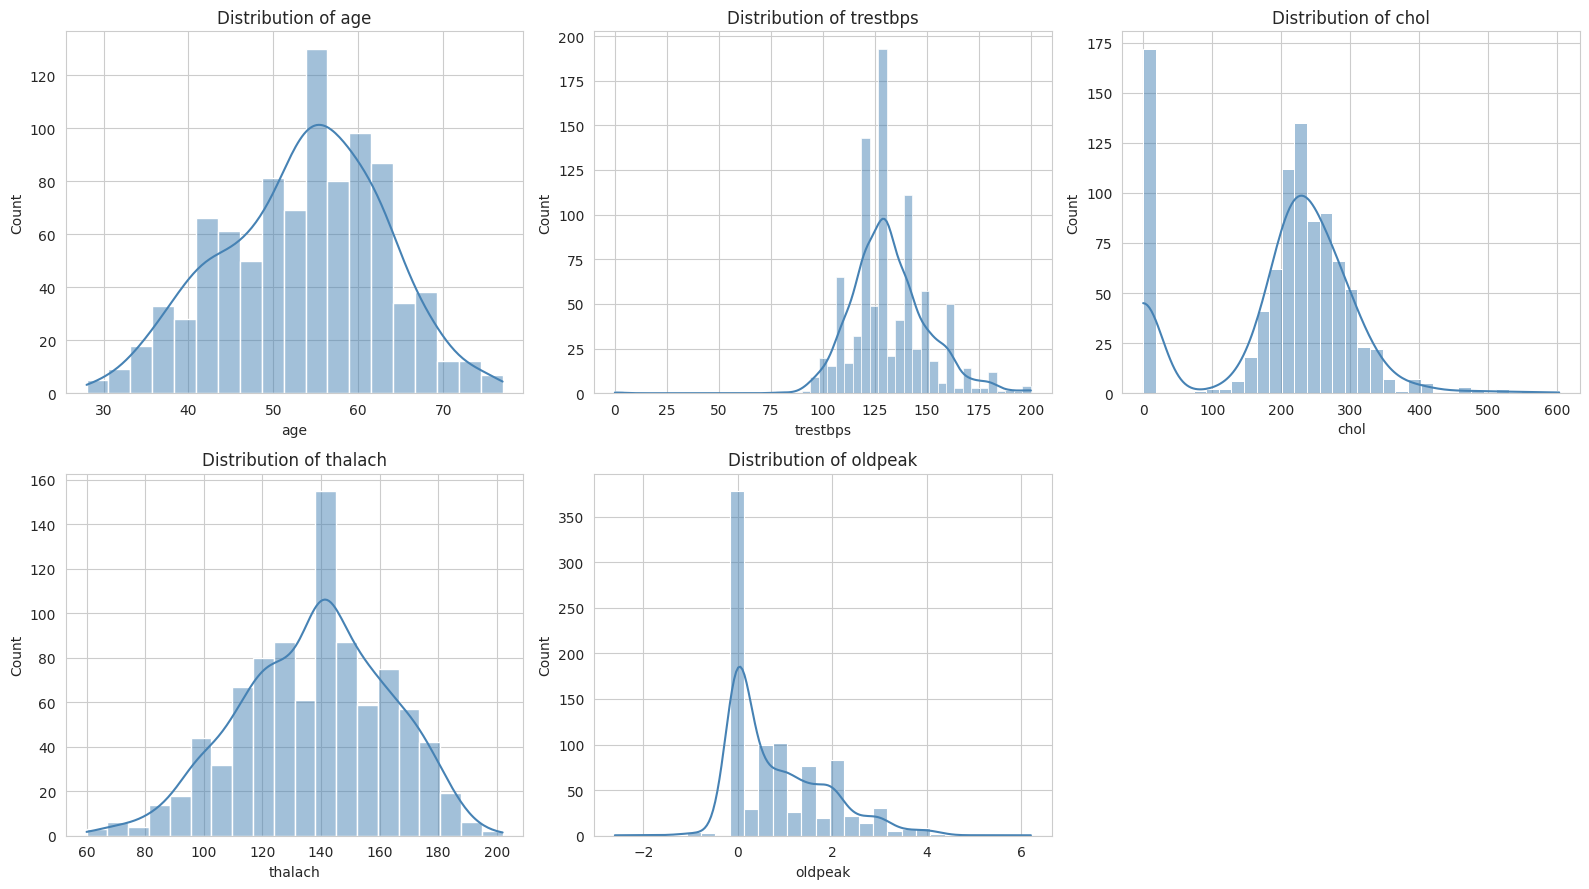

In [ ]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2381/924743093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_binary', y=col, data=df_clean, palette='Set2', ax=axes[i])
/tmp/ipykernel_2381/924743093.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No Disease', 'Disease'])
/tmp/ipykernel_2381/924743093.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_binary', y=col, data=df_clean, palette='Set2', ax=axes[i])
/tmp/ipykernel_2381/924743093.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_x

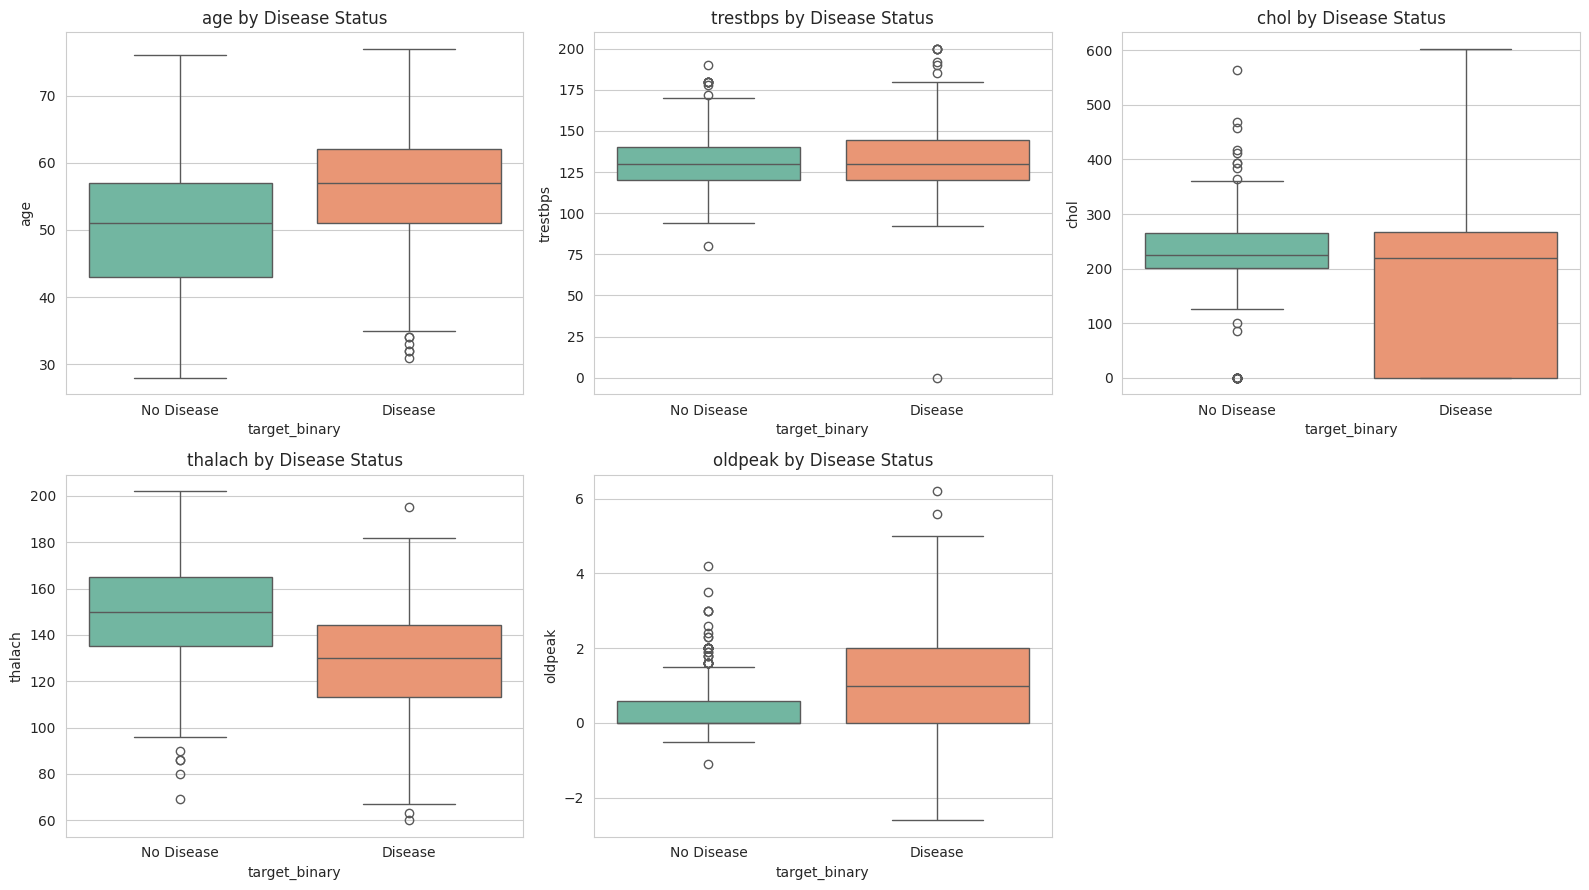

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='target_binary', y=col, data=df_clean, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} by Disease Status')
    axes[i].set_xticklabels(['No Disease', 'Disease'])
axes[-1].axis('off')
plt.tight_layout()
plt.show()

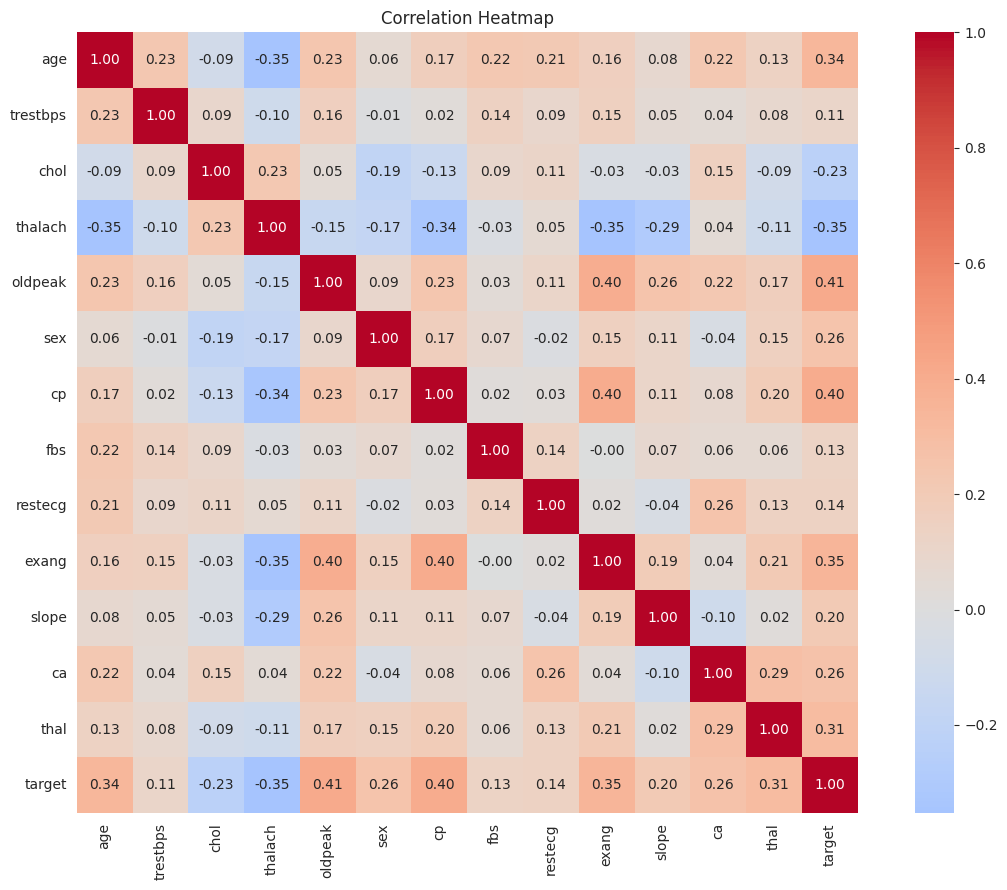

In [ ]:
corr_cols = numeric_cols + ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

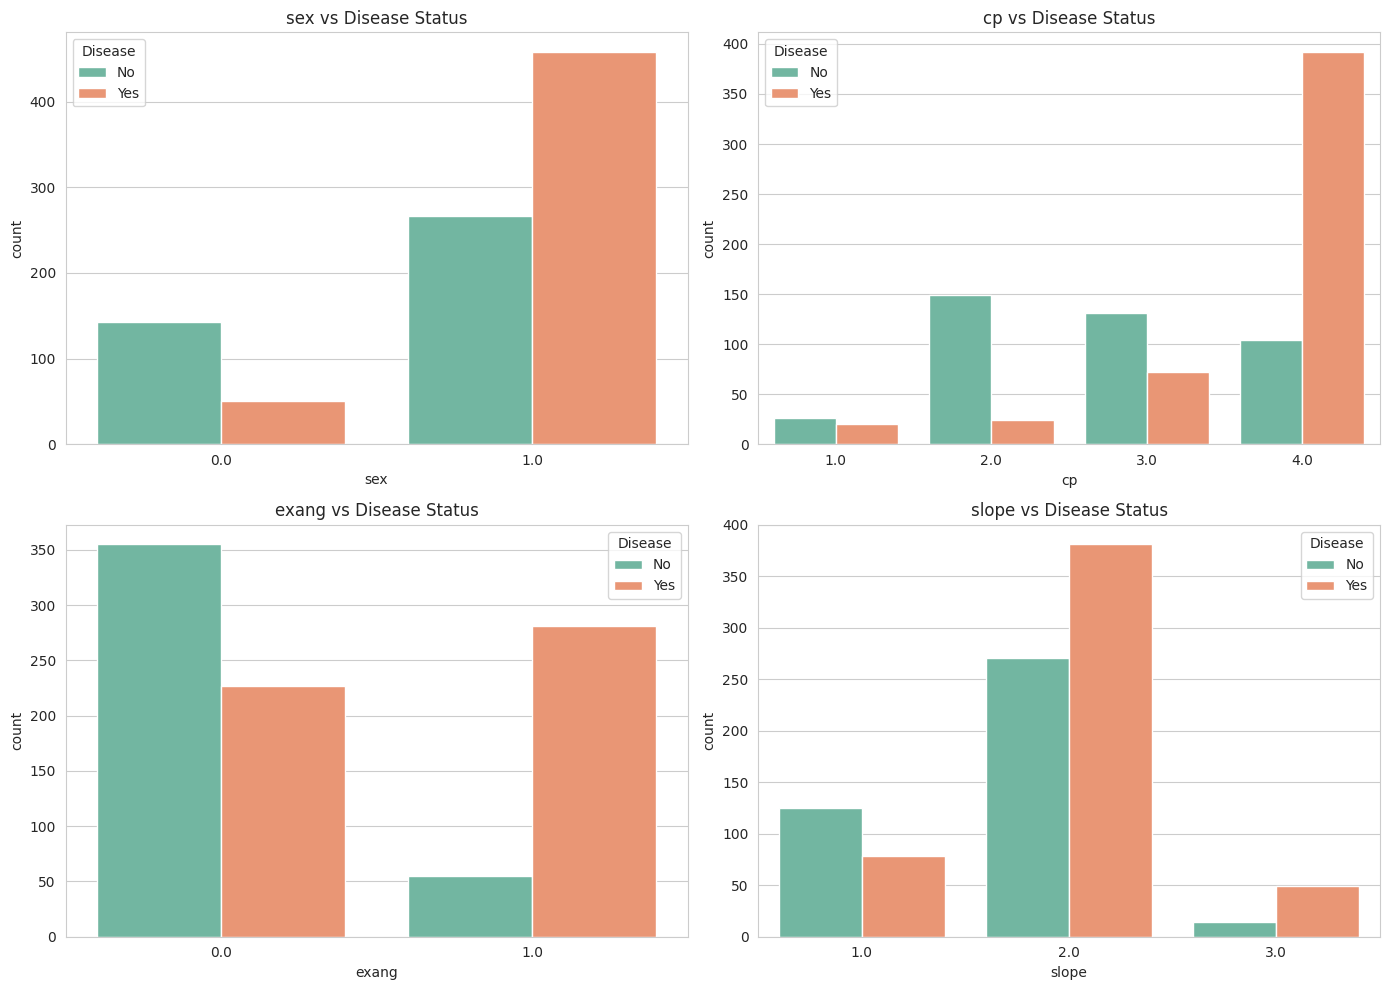

In [ ]:
cat_cols = ['sex', 'cp', 'exang', 'slope']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='target_binary', data=df_clean, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} vs Disease Status')
    axes[i].legend(title='Disease', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_2381/156523106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='source', data=df, palette='pastel',


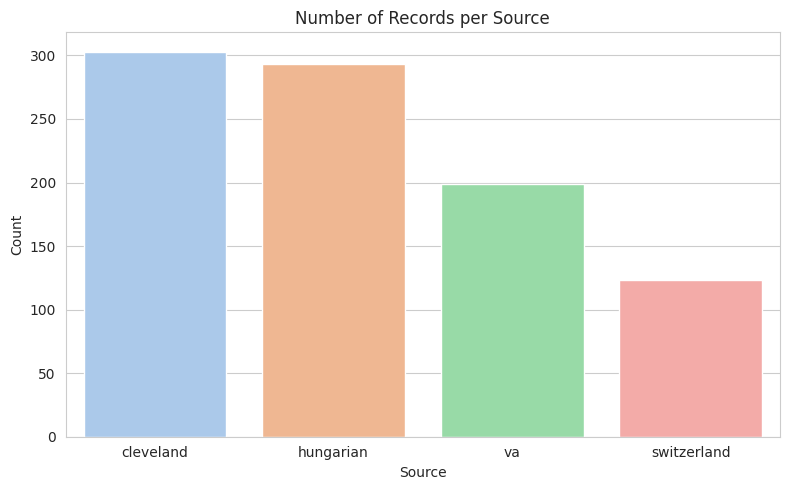

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='source', data=df, palette='pastel',
              order=df['source'].value_counts().index)
plt.title('Number of Records per Source')
plt.xlabel('Source')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42

In [ ]:
# Resolve paths whether this notebook is run from the project root or notebooks/.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_DIR / "data" / "raw" / "/content/heart_disease_combined (1).csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
print("Dataset:", DATA_PATH)
print("Dataset shape:", df.shape)

Dataset: /content/heart_disease_combined (1).csv
Dataset shape: (747, 15)


In [ ]:
print("Columns:")
print(df.columns.tolist())
print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))
print("\nOriginal target distribution:")
print(df["target"].value_counts(dropna=False).sort_index())
print("\nRecords per source:")
print(df["source"].value_counts(dropna=False))
df.head()

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'source']

Missing values per column:
ca          444
thal        394
slope       272
oldpeak      47
trestbps     46
exang        45
thalach      45
chol         29
fbs          10
restecg       1
cp            0
sex           0
age           0
target        0
source        0
dtype: int64

Original target distribution:
target
0    390
1    203
2     63
3     69
4     22
Name: count, dtype: int64

Records per source:
source
cleveland    303
hungarian    293
va           151
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [ ]:
if df["target"].isna().any():
    raise ValueError("The target contains missing values; resolve these before training.")
df = df.reset_index(drop=True)
target_column = "target_binary"
df[target_column] = (df["target"] > 0).astype("int8")
feature_columns = [c for c in df.columns if c not in {"target", target_column, "source"}]

categorical_candidates = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
categorical_features = [c for c in categorical_candidates if c in feature_columns]
numeric_features = [c for c in feature_columns if c not in categorical_features]

print("Input features:", feature_columns)
print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)
print("Target:", target_column)
print("Usable rows:", len(df))

Input features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Target: target_binary
Usable rows: 747


In [ ]:
target_counts = df[target_column].value_counts().sort_index()
target_proportions = df[target_column].value_counts(normalize=True).sort_index()
print("Class counts (0 = no disease, 1 = disease):")
print(target_counts)
print("\nClass proportions:")
print(target_proportions.round(4))

Class counts (0 = no disease, 1 = disease):
target_binary
0    390
1    357
Name: count, dtype: int64

Class proportions:
target_binary
0    0.5221
1    0.4779
Name: proportion, dtype: float64


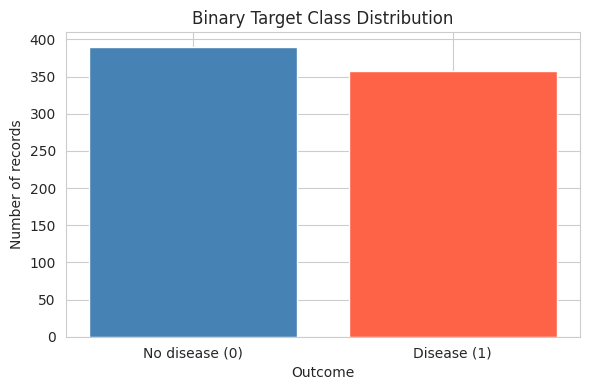

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(["No disease (0)", "Disease (1)"], [target_counts.get(0, 0), target_counts.get(1, 0)], color=["steelblue", "tomato"])
plt.title("Binary Target Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

In [ ]:
# SPLIT THE DATASET INTO TRAINING AND FINAL TEST DATA

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[target_column]
)

print("Training-period rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Training outcome proportions:")
print(train_df[target_column].value_counts(normalize=True).sort_index().round(3))
print("Testing outcome proportions:")
print(test_df[target_column].value_counts(normalize=True).sort_index().round(3))

Training-period rows: 597
Testing rows: 150
Training outcome proportions:
target_binary
0    0.523
1    0.477
Name: proportion, dtype: float64
Testing outcome proportions:
target_binary
0    0.52
1    0.48
Name: proportion, dtype: float64


In [ ]:
def validation_split(training_frame, validation_fraction=0.10):
    """Create stratified model-fit and validation data from training records."""
    fit_frame, validation_frame = train_test_split(
        training_frame,
        test_size=validation_fraction,
        random_state=RANDOM_STATE,
        stratify=training_frame[target_column]
    )
    return fit_frame, validation_frame


def build_tree(max_depth, min_samples_leaf):
    """Create preprocessing and a Decision Tree as one pipeline."""
    numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ], remainder="drop")
    return Pipeline([
        ("preprocess", preprocessor),
        ("tree", DecisionTreeClassifier(
            criterion="gini", max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, random_state=RANDOM_STATE
        )),
    ])


def classification_scores(y_true, predictions):
    """Calculate the main disease-class metrics."""
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
    }


fit_df, validation_df = validation_split(train_df)
print("Model-fit samples:", len(fit_df))
print("Validation samples:", len(validation_df))
print("Final test samples:", len(test_df))

Model-fit samples: 537
Validation samples: 60
Final test samples: 150


In [ ]:
parameter_options = [
    {"max_depth": 3, "min_samples_leaf": 5},
    {"max_depth": 5, "min_samples_leaf": 5},
    {"max_depth": 7, "min_samples_leaf": 5},
    {"max_depth": 10, "min_samples_leaf": 5},
    {"max_depth": 5, "min_samples_leaf": 10},
    {"max_depth": 7, "min_samples_leaf": 10},
    {"max_depth": 10, "min_samples_leaf": 10},
    {"max_depth": None, "min_samples_leaf": 20},
]
print("Number of Decision Tree varieties:", len(parameter_options))

Number of Decision Tree varieties: 8


In [ ]:
# SEPARATE THE MODEL-FIT AND VALIDATION FEATURES / TARGETS
X_fit = fit_df[feature_columns]
y_fit = fit_df[target_column]
X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

results = []
trained_models = {}

for params in parameter_options:

    model = build_tree(
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"]
    )

    # Train the Decision Tree pipeline.
    model.fit(X_fit, y_fit)

    # Predict the validation data.
    validation_predictions = model.predict(X_validation)

    # Calculate evaluation metrics.
    scores = classification_scores(y_validation, validation_predictions)

    # Check that the model predicts both classes.
    predicts_both_classes = len(np.unique(validation_predictions)) == 2
    model_name = (
        f"Depth={params['max_depth']}, "
        f"Leaf={params['min_samples_leaf']}"
    )
    trained_models[model_name] = model

    results.append({
        "Model": model_name,
        "Max Depth": params["max_depth"],
        "Min Samples Leaf": params["min_samples_leaf"],
        "Accuracy": scores["Accuracy"],
        "Precision": scores["Precision"],
        "Recall": scores["Recall"],
        "F1": scores["F1"],
        "Predicts Both Classes": predicts_both_classes,
    })

In [ ]:
results_df = pd.DataFrame(results)
valid_results = results_df[results_df["Predicts Both Classes"]].copy()
if valid_results.empty:
    valid_results = results_df.copy()
valid_results = valid_results.sort_values(
    by=["F1", "Accuracy"], ascending=False
).reset_index(drop=True)
display(valid_results.round(4))

,Model,Max Depth,Min Samples Leaf,Accuracy,Precision,Recall,F1,Predicts Both Classes
0,"Depth=7, Leaf=5",7.0,5,0.8000,0.7742,0.8276,0.8000,True
1,"Depth=3, Leaf=5",3.0,5,0.7833,0.7500,0.8276,0.7869,True
2,"Depth=5, Leaf=5",5.0,5,0.7500,0.7188,0.7931,0.7541,True
3,"Depth=10, Leaf=5",10.0,5,0.7500,0.7188,0.7931,0.7541,True
4,"Depth=5, Leaf=10",5.0,10,0.7333,0.6970,0.7931,0.7419,True
5,"Depth=7, Leaf=10",7.0,10,0.7333,0.6970,0.7931,0.7419,True
6,"Depth=10, Leaf=10",10.0,10,0.7333,0.6970,0.7931,0.7419,True
7,"Depth=None, Leaf=20",NaN,20,0.7333,0.7097,0.7586,0.7333,True


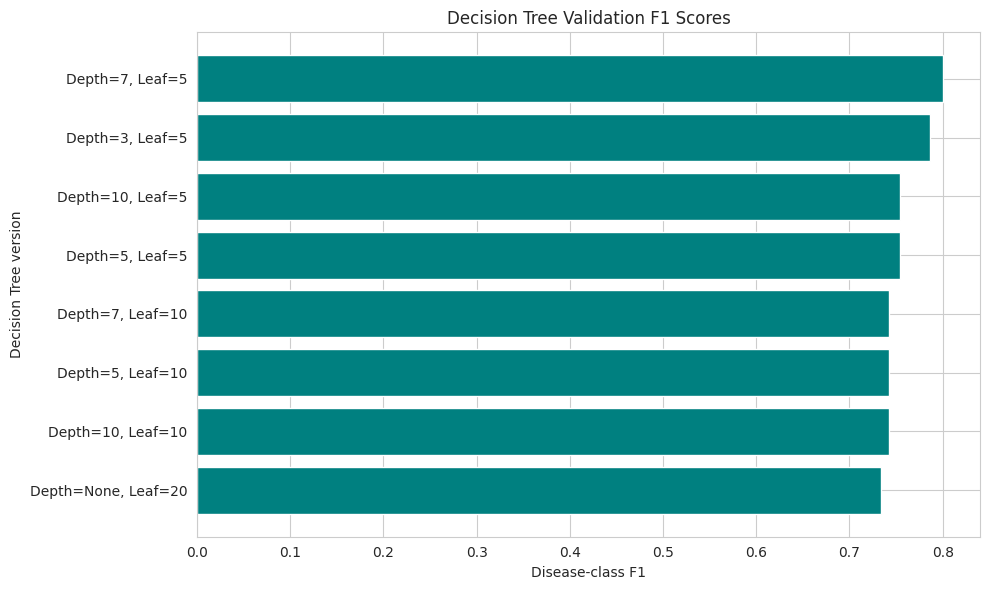

In [ ]:
plot_data = valid_results.sort_values("F1", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_data["Model"], plot_data["F1"], color="teal")
plt.title("Decision Tree Validation F1 Scores")
plt.xlabel("Disease-class F1")
plt.ylabel("Decision Tree version")
plt.tight_layout()
plt.show()

In [ ]:
best_result = valid_results.iloc[0]
best_model_name = best_result["Model"]
best_depth = best_result["Max Depth"]
best_leaf = int(best_result["Min Samples Leaf"])
print("Selected Decision Tree:", best_model_name)
print("Validation Accuracy:", round(best_result["Accuracy"], 4))
print("Validation Precision:", round(best_result["Precision"], 4))
print("Validation Recall:", round(best_result["Recall"], 4))
print("Validation F1:", round(best_result["F1"], 4))
print("Best max_depth:", best_depth)
print("Best min_samples_leaf:", best_leaf)

Selected Decision Tree: Depth=7, Leaf=5
Validation Accuracy: 0.8
Validation Precision: 0.7742
Validation Recall: 0.8276
Validation F1: 0.8
Best max_depth: 7.0
Best min_samples_leaf: 5


In [ ]:
print(repr(best_depth), type(best_depth))
print(repr(best_leaf), type(best_leaf))

np.float64(7.0) <class 'numpy.float64'>
5 <class 'int'>


In [ ]:
import pandas as pd

# Clean the tuned hyperparameters so scikit-learn accepts them
if best_depth is None or (isinstance(best_depth, str) and best_depth.lower() == "none") or pd.isna(best_depth):
    best_depth = None
else:
    best_depth = int(best_depth)

best_leaf = int(best_leaf)

# Create the selected Decision Tree pipeline.
cv_model = build_tree(
    max_depth=best_depth,
    min_samples_leaf=best_leaf
)

# Perform 5-fold cross-validation.
cv_scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=kfold,
    scoring="f1",
    n_jobs=-1,
    error_score="raise"
)

print("5-Fold Cross-Validation F1 Scores:")
print(np.round(cv_scores, 4))
print("Average Cross-Validation F1:", round(cv_scores.mean(), 4))

5-Fold Cross-Validation F1 Scores:
[0.7805 0.7541 0.6729 0.6783 0.7568]
Average Cross-Validation F1: 0.7285


In [ ]:
# Cast best_depth to integer if it is not None
resolved_depth = int(best_depth) if best_depth is not None else None

final_model = build_tree(resolved_depth, best_leaf)
final_model.fit(X_train, y_train)
print("Final Decision Tree pipeline trained successfully.")
print("max_depth:", resolved_depth)
print("min_samples_leaf:", best_leaf)

Final Decision Tree pipeline trained successfully.
max_depth: 7
min_samples_leaf: 5


In [ ]:
# FEATURES AND TARGET FROM THE UNSEEN FINAL TEST DATA
X_test = test_df[feature_columns]
y_test = test_df[target_column]

# Make final predictions.
final_predictions = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(y_test, final_predictions, zero_division=0)
final_recall = recall_score(y_test, final_predictions, zero_division=0)
final_f1 = f1_score(y_test, final_predictions, zero_division=0)
print("FINAL DECISION TREE RESULTS")
print("---------------------------")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

FINAL DECISION TREE RESULTS
---------------------------
Accuracy : 0.7800
Precision: 0.7532
Recall   : 0.8056
F1 Score : 0.7785


In [ ]:
prediction_counts = pd.Series(final_predictions).value_counts().sort_index()
print("Final prediction counts (0 = no disease, 1 = disease):")
print(prediction_counts)
print("\nClassification report:")
print(classification_report(
    y_test, final_predictions, target_names=["No disease", "Disease"],
    digits=4, zero_division=0
))

Final prediction counts (0 = no disease, 1 = disease):
0    73
1    77
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

  No disease     0.8082    0.7564    0.7815        78
     Disease     0.7532    0.8056    0.7785        72

    accuracy                         0.7800       150
   macro avg     0.7807    0.7810    0.7800       150
weighted avg     0.7818    0.7800    0.7800       150



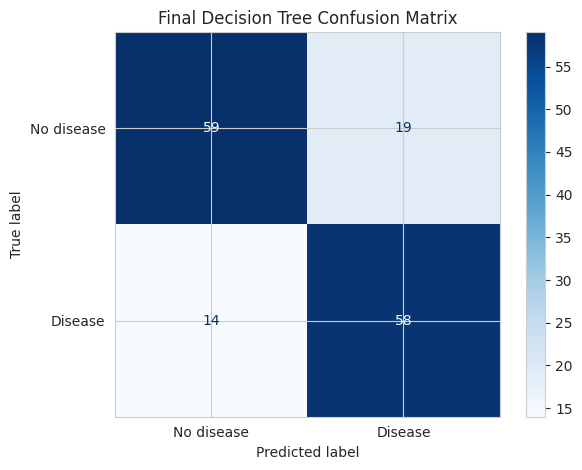

In [ ]:
cm = confusion_matrix(y_test, final_predictions, labels=[0, 1])
display_obj = ConfusionMatrixDisplay(cm, display_labels=["No disease", "Disease"])
display_obj.plot(cmap="Blues")
plt.title("Final Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
transformed_feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
feature_importance = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": final_model.named_steps["tree"].feature_importances_,
}).sort_values("Importance", ascending=False).reset_index(drop=True)
display(feature_importance.head(20).round(4))

,Feature,Importance
0,categorical__cp_4.0,0.4005
1,numeric__oldpeak,0.1337
2,numeric__age,0.1228
3,numeric__thalach,0.0941
4,numeric__trestbps,0.0371
5,categorical__sex_1.0,0.0348
6,categorical__fbs_1.0,0.0307
7,numeric__chol,0.0287
8,categorical__slope_2.0,0.0282
9,categorical__thal_3.0,0.0254


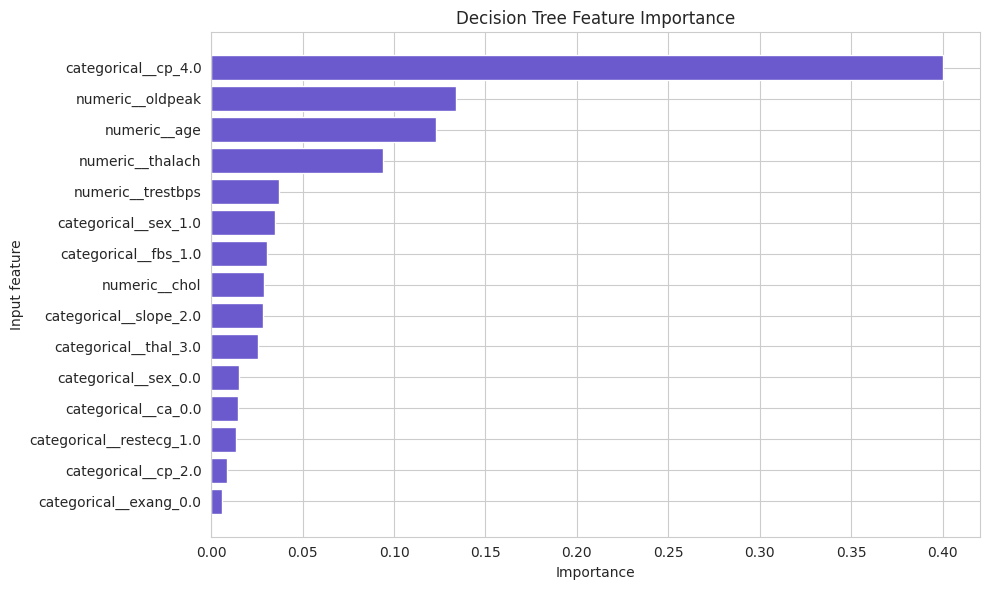

In [ ]:
plot_importance = feature_importance.head(15).sort_values("Importance", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_importance["Feature"], plot_importance["Importance"], color="slateblue")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Input feature")
plt.tight_layout()
plt.show()

In [ ]:
sample_index = X_test.index[:20]
sample_predictions = pd.DataFrame({
    "Source (context only)": df.loc[sample_index, "source"].values,
    "Original target": df.loc[sample_index, "target"].values,
    "Actual binary": y_test.loc[sample_index].values,
    "Predicted binary": final_predictions[:20],
})
sample_predictions

,Source (context only),Original target,Actual binary,Predicted binary
0,cleveland,2,1,1
1,hungarian,1,1,1
2,cleveland,0,0,0
3,cleveland,3,1,1
4,cleveland,0,0,1
5,cleveland,0,0,1
6,hungarian,0,0,0
7,hungarian,0,0,0
8,cleveland,0,0,1
9,hungarian,1,1,1


In [ ]:
MODEL_DIR = PROJECT_DIR / "models"
REPORT_DIR = PROJECT_DIR / "reports"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
model_package = {
    "model": final_model,
    "features": feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "target_column": target_column,
    "labels": {0: "No disease", 1: "Disease present"},
    "best_max_depth": best_depth,
    "best_min_samples_leaf": best_leaf,
}
model_path = MODEL_DIR / "heart_disease_decision_tree.joblib"
joblib.dump(model_package, model_path)
print("Model saved:", model_path)

valid_results.to_csv(REPORT_DIR / "decision_tree_model_comparison.csv", index=False)
final_results = pd.DataFrame([{
    "Model": "Decision Tree Classifier",
    "Best max_depth": best_depth,
    "Best min_samples_leaf": best_leaf,
    "Cross-Validation F1": cv_scores.mean(),
    "Test Accuracy": final_accuracy,
    "Test Precision": final_precision,
    "Test Recall": final_recall,
    "Test F1": final_f1,
}])
final_results.to_csv(REPORT_DIR / "decision_tree_final_results.csv", index=False)
print("Comparison and final results saved under:", REPORT_DIR)
final_results

Model saved: /content/models/heart_disease_decision_tree.joblib
Comparison and final results saved under: /content/reports


,Model,Best max_depth,Best min_samples_leaf,Cross-Validation F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Decision Tree Classifier,7,5,0.7285,0.78,0.753247,0.805556,0.778523
